In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [2]:
planes = pd.read_csv('flights.csv')

/var/folders/6x/cw89xb1x1f7c87g5_m1hrq040000gn/T/ipykernel_28118/1768364393.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  planes = pd.read_csv('flights.csv')


In [3]:
planes.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
planes['CANCELLATION_REASON'].unique()

<ArrowStringArray>
[nan, 'A', 'B', 'C', 'D']
Length: 5, dtype: str

In [5]:
planes['MONTH']

0           1
1           1
2           1
3           1
4           1
           ..
5819074    12
5819075    12
5819076    12
5819077    12
5819078    12
Name: MONTH, Length: 5819079, dtype: int64

In [6]:
planes.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON        str
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [7]:
planes.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [8]:
planes.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


# Fully naming the airlines

In [9]:
airlines = {
    "UA": "United Air Lines Inc.",
    "AA": "American Airlines Inc.",
    "US": "US Airways Inc.",
    "F9": "Frontier Airlines Inc.",
    "B6": "JetBlue Airways",
    "OO": "Skywest Airlines Inc.",
    "AS": "Alaska Airlines Inc.",
    "NK": "Spirit Air Lines",
    "WN": "Southwest Airlines Co.",
    "DL": "Delta Air Lines Inc.",
    "EV": "Atlantic Southeast Airlines",
    "HA": "Hawaiian Airlines Inc.",
    "MQ": "American Eagle Airlines Inc.",
    "VX": "Virgin America"
}

planes['AIRLINE_NAME'] = planes['AIRLINE'].map(airlines)
planes['AIRLINE_NAME']

0            Alaska Airlines Inc.
1          American Airlines Inc.
2                 US Airways Inc.
3          American Airlines Inc.
4            Alaska Airlines Inc.
                    ...          
5819074           JetBlue Airways
5819075           JetBlue Airways
5819076           JetBlue Airways
5819077           JetBlue Airways
5819078           JetBlue Airways
Name: AIRLINE_NAME, Length: 5819079, dtype: str

In [10]:
cancel_reasons = {
    'A' : 'Airline/Carrier',
    'B' : 'Weather',
    'C' : 'National Air System',
    'D' : 'Security',  
}

planes['CANCELLATION_REASON'] = planes['CANCELLATION_REASON'].map(cancel_reasons)

# Extracting the number of flights that have been cancelled in each month

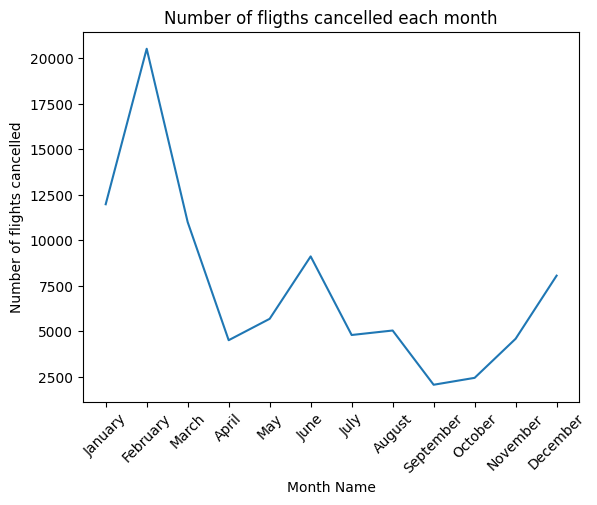

In [11]:
import calendar

cancel_month = (
    planes[planes['CANCELLED'] == 1].groupby(['MONTH', 'CANCELLED'])
    .size()
    .reset_index(name='count')
)

cancel_month['MONTH'] = cancel_month['MONTH'].apply(lambda x: calendar.month_name[x])

sns.lineplot(
    data=cancel_month,
    x='MONTH',
    y='count'
)

plt.title("Number of fligths cancelled each month")
plt.xlabel("Month Name")
plt.ylabel("Number of flights cancelled")
plt.xticks(rotation=45)
plt.show()

### As we can see a large amount of flights have been cancelled in February lets see on which day of the month it was the most cancelled

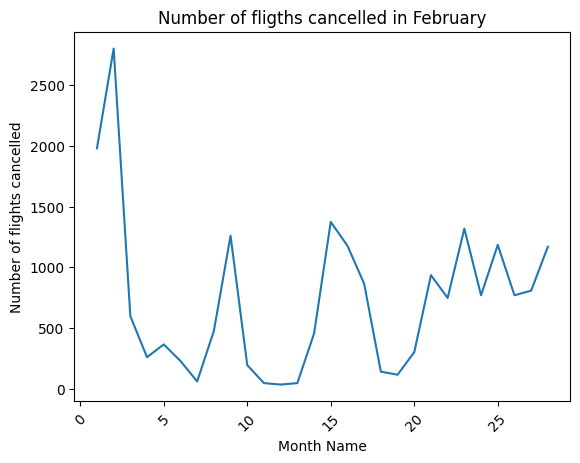

In [12]:
cancel_month = (
    planes[(planes['CANCELLED'] == 1) & (planes['MONTH'] == 2)].groupby(['DAY', 'CANCELLED'])
    .size()
    .reset_index(name='count')
)

sns.lineplot(
    data=cancel_month,
    x='DAY',
    y='count'
)

plt.title("Number of fligths cancelled in February")
plt.xlabel("Month Name")
plt.ylabel("Number of flights cancelled")
plt.xticks(rotation=45)
plt.show()

# Lets see the reasons for which these flights were cancelled in February

### Weather was a major factor for the delay reason in feb

<Axes: xlabel='DAY', ylabel='count'>

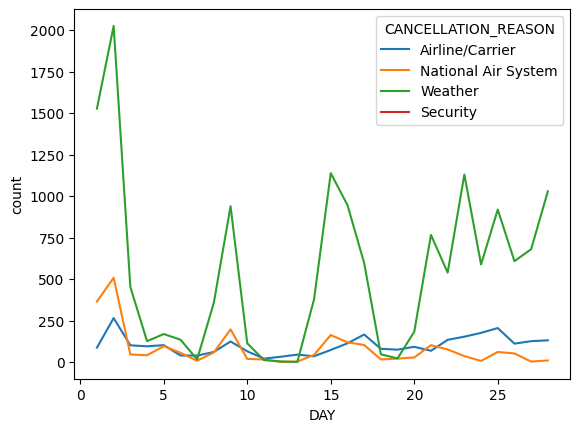

In [13]:

delay_reasons = (
planes[(planes['CANCELLED'] == 1) & (planes['MONTH'] == 2)].groupby(['DAY', 'CANCELLED','CANCELLATION_REASON'])
.size()
.reset_index(name='count')
)


sns.lineplot(
    data=delay_reasons,
    x='DAY',
    y='count',
    hue='CANCELLATION_REASON',
)


# Flights which cancelled the most

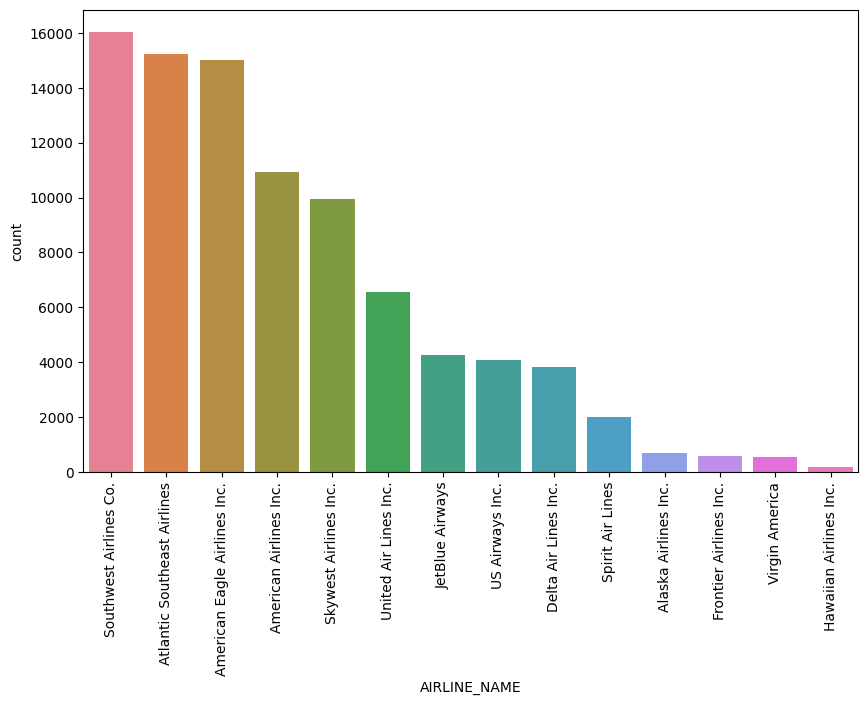

In [14]:
cancell_quantity_by_airline = (
    planes[planes['CANCELLED'] == 1].groupby(['AIRLINE_NAME', 'CANCELLED'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count',ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='AIRLINE_NAME',
    y='count',
    hue='AIRLINE_NAME',
    data=cancell_quantity_by_airline
)
plt.xticks(rotation=90)
plt.show()

# Number of cancellations by an airline

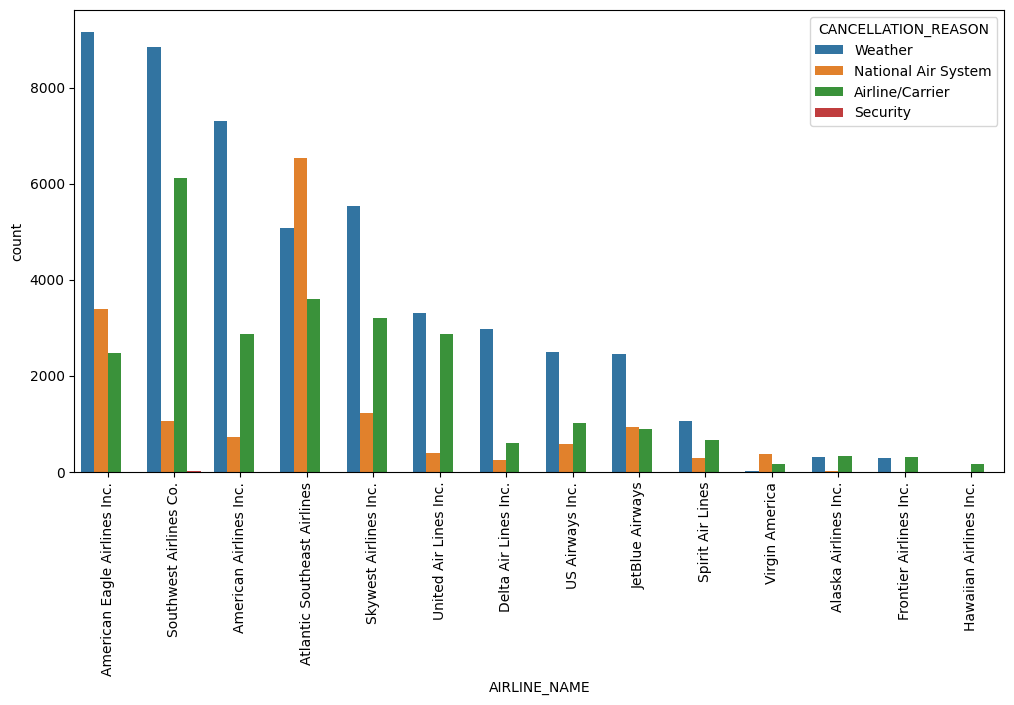

In [15]:
cancell_quantity_by_airline = (
    planes[planes['CANCELLED'] == 1]
    .groupby(['AIRLINE_NAME', 'CANCELLATION_REASON'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='AIRLINE_NAME',
    y='count',
    hue='CANCELLATION_REASON',
    data=cancell_quantity_by_airline
)

plt.xticks(rotation=90)
plt.show()

   CANCELLATION_REASON  count
3              Weather   9164
1  National Air System   3385
0      Airline/Carrier   2475
2             Security      1


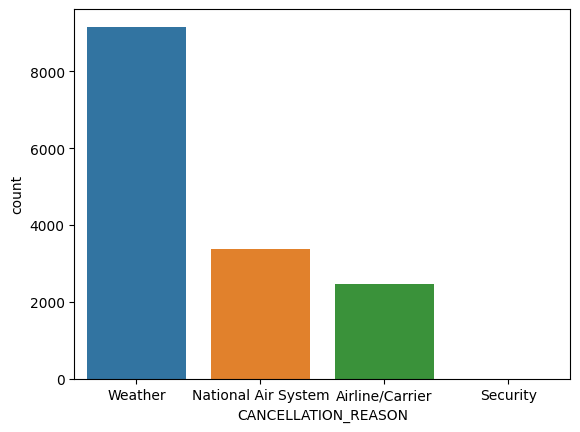

In [16]:
cancell_quantity_by_airline = (
    planes[(planes['CANCELLED'] == 1) & (planes['AIRLINE'] == 'MQ')]
    .groupby('CANCELLATION_REASON')
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

print(cancell_quantity_by_airline)


sns.barplot(
    x='CANCELLATION_REASON',
    y='count',
    hue='CANCELLATION_REASON',
    data=cancell_quantity_by_airline
)

plt.show()

In [17]:
# planes[['CANCELLATION_REASON','AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']].head(20)
planes[['CANCELLATION_REASON','AIR_SYSTEM_DELAY']][planes[['CANCELLATION_REASON','WEATHER_DELAY']].notna().any(axis=1)]

,CANCELLATION_REASON,AIR_SYSTEM_DELAY
27,NaN,25.0
30,NaN,43.0
32,Airline/Carrier,NaN
35,NaN,0.0
42,Weather,NaN
...,...,...
5819023,NaN,0.0
5819051,NaN,12.0
5819057,NaN,15.0
5819069,NaN,0.0


In [18]:
planes.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON        str
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
AIRLINE_NAME               str
dtype: o

In [19]:
cols = ['SECURITY_DELAY','AIRLINE_DELAY','AIR_SYSTEM_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']

for col in cols:
    planes[col]=planes[col].fillna(0)

In [20]:
planes.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY             0
SECURITY_DELAY               0
AIRLINE_DELAY                0
LATE_AIRCRAFT_DELAY          0
WEATHER_DELAY                0
AIRLINE_NAME                 0
dtype: i

In [21]:
planes['ARRIVAL_DELAY']

0         -22.0
1          -9.0
2           5.0
3          -9.0
4         -21.0
           ... 
5819074   -26.0
5819075   -16.0
5819076    -8.0
5819077   -10.0
5819078     2.0
Name: ARRIVAL_DELAY, Length: 5819079, dtype: float64

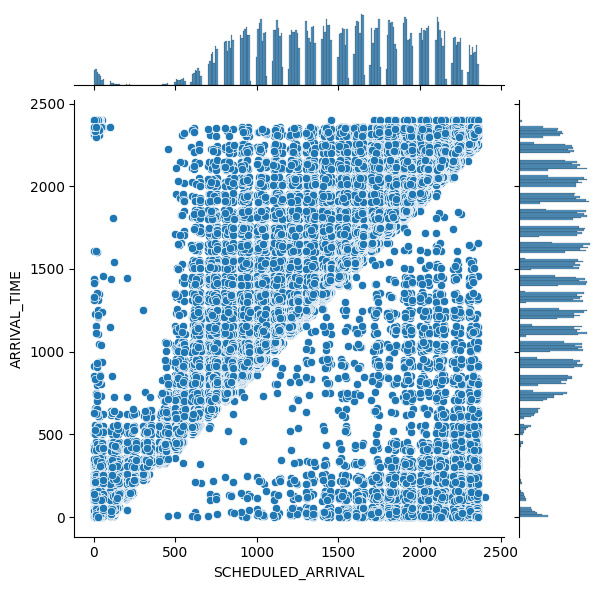

In [22]:
sns.jointplot(data=planes, x="SCHEDULED_ARRIVAL", y="ARRIVAL_TIME")

In [23]:
planes.corr(numeric_only=True)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
YEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MONTH,NaN,1.000000,0.008874,-0.007847,-0.020746,0.000207,-0.004085,-0.021994,-0.013117,-0.004946,...,-0.010121,-0.009133,-0.036793,-0.000991,-0.055043,-0.016943,0.002099,-0.008968,-0.015900,-0.008840
DAY,NaN,0.008874,1.000000,0.001111,0.001855,-0.001647,-0.002644,-0.000176,-0.002661,-0.003318,...,-0.003688,-0.004310,-0.003097,0.001981,-0.003537,-0.005845,-0.000456,0.000233,0.000147,0.002825
DAY_OF_WEEK,NaN,-0.007847,0.001111,1.000000,0.014461,0.008007,0.005607,-0.011510,-0.020639,0.004060,...,0.007092,0.005641,-0.017027,-0.001442,-0.022230,-0.013891,0.000296,0.000600,-0.012028,-0.004359
FLIGHT_NUMBER,NaN,-0.020746,0.001855,0.014461,1.000000,-0.005485,-0.001444,-0.008665,0.050369,0.005289,...,-0.013947,-0.002821,0.018419,0.003802,0.037895,-0.001626,-0.003304,0.004657,0.010948,-0.000564
SCHEDULED_DEPARTURE,NaN,0.000207,-0.001647,0.008007,-0.005485,1.000000,0.963791,0.110149,0.006581,0.938008,...,0.706237,0.629342,0.100220,-0.000752,0.011752,0.026141,0.002296,0.011516,0.111929,0.011897
DEPARTURE_TIME,NaN,-0.004085,-0.002644,0.005607,-0.001444,0.963791,1.000000,0.171723,0.014002,0.971971,...,0.710223,0.648265,0.159787,0.001425,0.008055,0.055823,0.003878,0.051628,0.150034,0.021588
DEPARTURE_DELAY,NaN,-0.021994,-0.000176,-0.011510,-0.008665,0.110149,0.171723,1.000000,0.058515,0.162582,...,0.097566,0.049236,0.944672,0.022963,0.033099,0.302417,0.028067,0.653523,0.647186,0.263490
TAXI_OUT,NaN,-0.013117,-0.002661,-0.020639,0.050369,0.006581,0.014002,0.058515,1.000000,0.039104,...,0.024384,0.029745,0.227319,0.012251,0.005062,0.337070,0.003718,0.036223,0.027782,0.076862
WHEELS_OFF,NaN,-0.004946,-0.003318,0.004060,0.005289,0.938008,0.971971,0.162582,0.039104,1.000000,...,0.721877,0.667991,0.155773,0.001667,0.004805,0.062704,0.003229,0.048171,0.140830,0.019875


<Axes: >

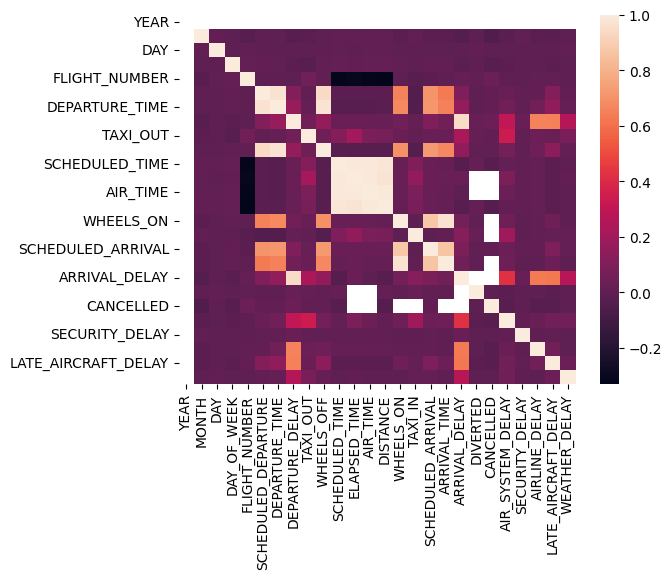

In [24]:
sns.heatmap(planes.corr(numeric_only=True))

In [25]:
planes=planes.drop(['YEAR','FLIGHT_NUMBER','AIRLINE','DISTANCE','TAIL_NUMBER','TAXI_OUT',
                                              'SCHEDULED_TIME','DEPARTURE_TIME','WHEELS_OFF','ELAPSED_TIME',
                                              'AIR_TIME','WHEELS_ON','DAY_OF_WEEK','TAXI_IN','CANCELLATION_REASON','AIRLINE_NAME'],
                                             axis=1)

In [26]:
planes

,MONTH,DAY,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,1,1,ANC,SEA,5,-11.0,430,408.0,-22.0,0,0,0.0,0.0,0.0,0.0,0.0
1,1,1,LAX,PBI,10,-8.0,750,741.0,-9.0,0,0,0.0,0.0,0.0,0.0,0.0
2,1,1,SFO,CLT,20,-2.0,806,811.0,5.0,0,0,0.0,0.0,0.0,0.0,0.0
3,1,1,LAX,MIA,20,-5.0,805,756.0,-9.0,0,0,0.0,0.0,0.0,0.0,0.0
4,1,1,SEA,ANC,25,-1.0,320,259.0,-21.0,0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,12,31,LAX,BOS,2359,-4.0,819,753.0,-26.0,0,0,0.0,0.0,0.0,0.0,0.0
5819075,12,31,JFK,PSE,2359,-4.0,446,430.0,-16.0,0,0,0.0,0.0,0.0,0.0,0.0
5819076,12,31,JFK,SJU,2359,-9.0,440,432.0,-8.0,0,0,0.0,0.0,0.0,0.0,0.0
5819077,12,31,MCO,SJU,2359,-6.0,340,330.0,-10.0,0,0,0.0,0.0,0.0,0.0,0.0


In [28]:
delay_cols = [
    'AIR_SYSTEM_DELAY',
    'WEATHER_DELAY',
    'AIRLINE_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]
planes[delay_cols] = planes[delay_cols].fillna(0)

In [29]:
result = []
for row in planes['ARRIVAL_DELAY']:
  if row > 15:
    result.append(1)
  else:
    result.append(0)  

In [31]:
planes['result'] = result

In [32]:
planes.value_counts('result')

result
0    4795581
1    1023498
Name: count, dtype: int64

In [33]:
planes

,MONTH,DAY,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,result
0,1,1,ANC,SEA,5,-11.0,430,408.0,-22.0,0,0,0.0,0.0,0.0,0.0,0.0,0
1,1,1,LAX,PBI,10,-8.0,750,741.0,-9.0,0,0,0.0,0.0,0.0,0.0,0.0,0
2,1,1,SFO,CLT,20,-2.0,806,811.0,5.0,0,0,0.0,0.0,0.0,0.0,0.0,0
3,1,1,LAX,MIA,20,-5.0,805,756.0,-9.0,0,0,0.0,0.0,0.0,0.0,0.0,0
4,1,1,SEA,ANC,25,-1.0,320,259.0,-21.0,0,0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,12,31,LAX,BOS,2359,-4.0,819,753.0,-26.0,0,0,0.0,0.0,0.0,0.0,0.0,0
5819075,12,31,JFK,PSE,2359,-4.0,446,430.0,-16.0,0,0,0.0,0.0,0.0,0.0,0.0,0
5819076,12,31,JFK,SJU,2359,-9.0,440,432.0,-8.0,0,0,0.0,0.0,0.0,0.0,0.0,0
5819077,12,31,MCO,SJU,2359,-6.0,340,330.0,-10.0,0,0,0.0,0.0,0.0,0.0,0.0,0


In [34]:
planes=planes.drop(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ARRIVAL_TIME', 'ARRIVAL_DELAY'],axis=1)
planes

,MONTH,DAY,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,result
0,1,1,5,-11.0,430,0,0,0.0,0.0,0.0,0.0,0.0,0
1,1,1,10,-8.0,750,0,0,0.0,0.0,0.0,0.0,0.0,0
2,1,1,20,-2.0,806,0,0,0.0,0.0,0.0,0.0,0.0,0
3,1,1,20,-5.0,805,0,0,0.0,0.0,0.0,0.0,0.0,0
4,1,1,25,-1.0,320,0,0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,12,31,2359,-4.0,819,0,0,0.0,0.0,0.0,0.0,0.0,0
5819075,12,31,2359,-4.0,446,0,0,0.0,0.0,0.0,0.0,0.0,0
5819076,12,31,2359,-9.0,440,0,0,0.0,0.0,0.0,0.0,0.0,0
5819077,12,31,2359,-6.0,340,0,0,0.0,0.0,0.0,0.0,0.0,0


<Axes: >

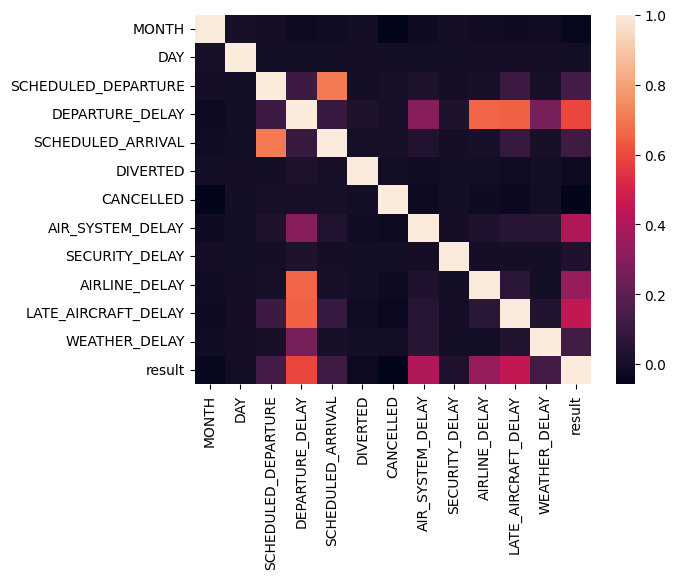

In [36]:
sns.heatmap(planes.corr())

In [39]:
feature = planes.drop(columns='result').values 
target = planes['result'].values

X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.30, random_state=42)

In [40]:
scaled_features = StandardScaler().fit_transform(X_train, X_test)

In [41]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)

In [42]:
pred_prob = clf.predict_proba(X_test)
auc_score = roc_auc_score(y_test, pred_prob[:,1])
auc_score

0.9996719619954411